In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

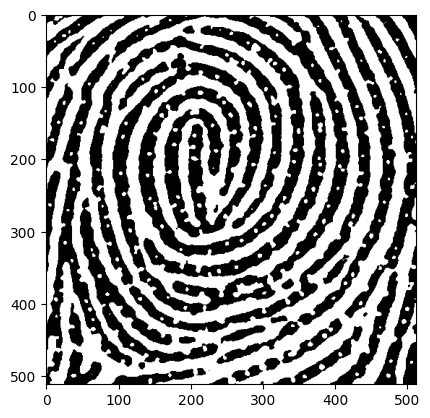

In [21]:
img = cv2.imread("../images/50_whorl.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.threshold(img, 127, 255, cv2.THRESH_OTSU + cv2.THRESH_BINARY)[1]

H = img.shape[0]
W = img.shape[1]

plt.imshow(img, cmap='gray')

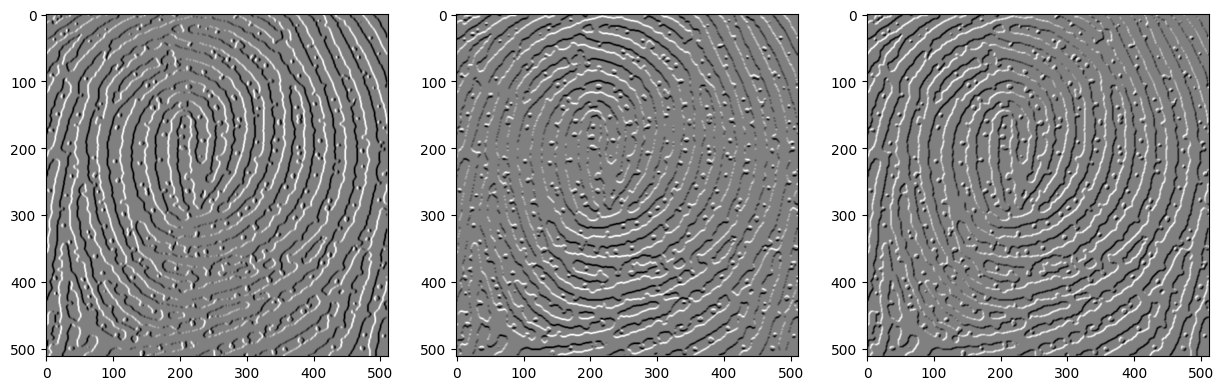

In [22]:
edge_horiz = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
edge_vert = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)

plt.subplots(1, 3, figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(edge_horiz, cmap='gray')

plt.subplot(1, 3, 2)
plt.imshow(edge_vert, cmap='gray')

plt.subplot(1, 3, 3)
plt.imshow(edge_horiz + edge_vert, cmap='gray')

In [26]:
I = cv2.GaussianBlur(img, (3, 3), 1.5)

J11 = cv2.boxFilter(edge_horiz * edge_horiz, cv2.CV_64F, (16, 16))
J22 = cv2.boxFilter(edge_vert * edge_vert, cv2.CV_64F, (16, 16))
J12 = cv2.boxFilter(edge_horiz * edge_vert, cv2.CV_64F, (16, 16))

theta = 0.5 * np.arctan2(2 * J12, J11 - J22)
theta

array([[ 1.45960809,  1.45960809,  1.45330248, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.45960809,  1.45960809,  1.45330248, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.44878665,  1.44878665,  1.45778823, ..., -0.78539816,
         0.        ,  0.        ],
       ...,
       [ 0.12092515,  0.12092515,  0.11543732, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.13480645,  0.13480645,  0.14369624, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.1506232 ,  0.1506232 ,  0.17176691, ...,  0.        ,
         0.        ,  0.        ]], shape=(512, 512))

In [ ]:
coh = np.sqrt((J11 - J22) ** 2 + 4 * J12**2) / (J11 + J22 + 1e-8)

block = 16
f_map = np.full_like(I, np.nan, dtype=float)

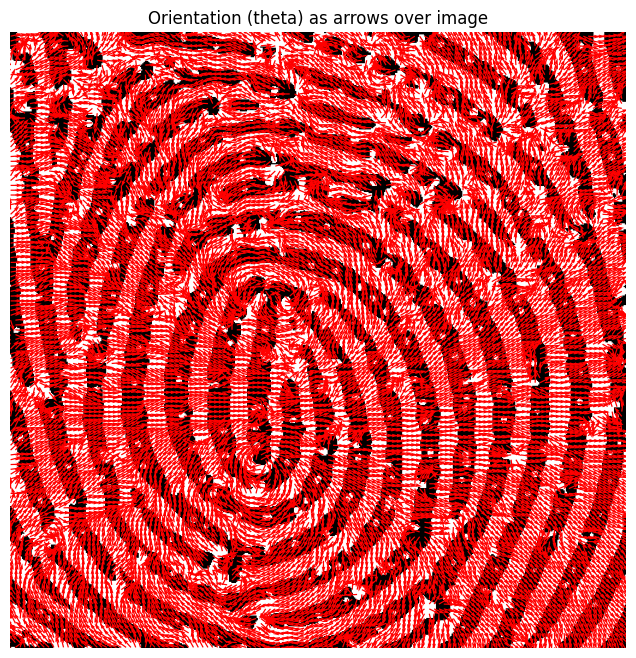

In [ ]:
# Choose a stride equal to the block size to make arrows readable
stride = 16
ys = np.arange(0, theta.shape[0], stride)
xs = np.arange(0, theta.shape[1], stride)
X, Y = np.meshgrid(xs, ys)
# Sample the theta values at the grid points (rows, cols)
theta_sample = theta[Y, X]
# Compute arrow components (cos, sin) — these point along the orientation
U = np.cos(2 * theta_sample)
V = np.sin(2 * theta_sample)

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray')
# quiver expects X,Y in image coords (cols, rows) — so pass X and Y
plt.quiver(X, Y, U, V, color="red", angles="xy", scale_units="xy", scale=0.1, width=0.002)
plt.gca().invert_yaxis()
plt.title('Orientation (theta) as arrows over image')
plt.axis('off')
plt.show()